In [1]:
# coding: utf-8
import sys
sys.path.append('..')
from common.np import *  # import numpy as np
from common.layers import Embedding, SigmoidWithLoss
import collections


class EmbeddingDot:
    def __init__(self, W):
        self.embed = Embedding(W)
        self.params = self.embed.params
        self.grads = self.embed.grads
        self.cache = None

    def forward(self, h, idx):
        target_W = self.embed.forward(idx)
        out = np.sum(target_W * h, axis=1)

        self.cache = (h, target_W)
        return out

    def backward(self, dout):
        h, target_W = self.cache
        dout = dout.reshape(dout.shape[0], 1)

        dtarget_W = dout * h
        self.embed.backward(dtarget_W)
        dh = dout * target_W
        return dh


class UnigramSampler:
    def __init__(self, corpus, power, sample_size):
        self.sample_size = sample_size
        self.vocab_size = None
        self.word_p = None

        counts = collections.Counter()
        for word_id in corpus:
            counts[word_id] += 1

        vocab_size = len(counts)
        self.vocab_size = vocab_size

        self.word_p = np.zeros(vocab_size)
        for i in range(vocab_size):
            self.word_p[i] = counts[i]

        self.word_p = np.power(self.word_p, power)
        self.word_p /= np.sum(self.word_p)

    def get_negative_sample(self, target):
        batch_size = target.shape[0]

        if not GPU:
            negative_sample = np.zeros((batch_size, self.sample_size), dtype=np.int32)

            for i in range(batch_size):
                p = self.word_p.copy()
                target_idx = target[i]
                p[target_idx] = 0
                p /= p.sum()
                negative_sample[i, :] = np.random.choice(self.vocab_size, size=self.sample_size, replace=False, p=p)
        else:
            # GPU(cupy）로 계산할 때는 속도를 우선한다.
            # 부정적 예에 타깃이 포함될 수 있다.
            negative_sample = np.random.choice(self.vocab_size, size=(batch_size, self.sample_size),
                                               replace=True, p=self.word_p)

        return negative_sample


class NegativeSamplingLoss:
    def __init__(self, W, corpus, power=0.75, sample_size=5):
        self.sample_size = sample_size
        self.sampler = UnigramSampler(corpus, power, sample_size)
        self.loss_layers = [SigmoidWithLoss() for _ in range(sample_size + 1)]
        self.embed_dot_layers = [EmbeddingDot(W) for _ in range(sample_size + 1)]

        self.params, self.grads = [], []
        for layer in self.embed_dot_layers:
            self.params += layer.params
            self.grads += layer.grads

    def forward(self, h, target):
        batch_size = target.shape[0]
        negative_sample = self.sampler.get_negative_sample(target)

        # 긍정적 예 순전파
        score = self.embed_dot_layers[0].forward(h, target)
        correct_label = np.ones(batch_size, dtype=np.int32)
        loss = self.loss_layers[0].forward(score, correct_label)

        # 부정적 예 순전파
        negative_label = np.zeros(batch_size, dtype=np.int32)
        for i in range(self.sample_size):
            negative_target = negative_sample[:, i]
            score = self.embed_dot_layers[1 + i].forward(h, negative_target)
            loss += self.loss_layers[1 + i].forward(score, negative_label)

        return loss

    def backward(self, dout=1):
        dh = 0
        for l0, l1 in zip(self.loss_layers, self.embed_dot_layers):
            dscore = l0.backward(dout)
            dh += l1.backward(dscore)

        return dh


In [5]:
import os
import pickle
from common.trainer import Trainer
from common.optimizer import Adam

# 현재 작업 디렉토리를 기준으로 ROOT 경로 설정
ROOT = os.getenv('NLP1_ROOT', os.path.abspath(os.getcwd()))

def src_path(*paths):
    return os.path.join(ROOT, 'source', 'deep-learning-from-scratch-2', *paths)

def common_path(*paths):
    return os.path.join(ROOT, 'common', *paths)

# 동적으로 경로 추가
import sys
sys.path.append(os.path.join(ROOT, 'source', 'deep-learning-from-scratch-2'))
sys.path.append(os.path.join(ROOT, 'common'))

# 경로가 제대로 설정되었는지 확인 (디버깅용)
print(f"ROOT: {ROOT}")
print(f"Source path: {src_path()}")
print(f"Common path: {common_path()}")

from ch04.cbow import CBOW
from ch04.skip_gram import SkipGram
from common.util import create_contexts_target, to_cpu, to_gpu
import ptb
import config
import numpy as np

# 하이퍼파라미터 설정
window_size = 5
hidden_size = 100
batch_size = 100
max_epoch = 10

# 데이터 읽기
corpus, word_to_id, id_to_word = ptb.load_data('train')
vocab_size = len(word_to_id)

contexts, target = create_contexts_target(corpus, window_size)
if config.GPU:
    contexts, target = to_gpu(contexts), to_gpu(target)


ROOT: /Users/minu/Desktop/4-1/NLP1
Source path: /Users/minu/Desktop/4-1/NLP1/source/deep-learning-from-scratch-2
Common path: /Users/minu/Desktop/4-1/NLP1/common


In [6]:

# 모델/옵티마이저/트레이너 정의
model = CBOW(vocab_size, hidden_size, window_size, corpus)
optimizer = Adam()
trainer = Trainer(model, optimizer)

# 학습 시작
trainer.fit(contexts, target, max_epoch, batch_size)
trainer.plot()

# 나중에 사용할 수 있도록 파라미터 저장
word_vecs = model.word_vecs
if config.GPU:
    word_vecs = to_cpu(word_vecs)

params = {}
params['word_vecs'] = word_vecs.astype(np.float16)
params['word_to_id'] = word_to_id
params['id_to_word'] = id_to_word

pkl_file = 'source/deep-learning-from-scratch-2/ch04/cbow_params.pkl'  # or 'skipgram_params.pkl'
with open(pkl_file, 'wb') as f:
    pickle.dump(params, f, -1)

| 에폭 1 |  반복 1 / 9295 | 시간 0[s] | 손실 4.16
| 에폭 1 |  반복 21 / 9295 | 시간 0[s] | 손실 4.16
| 에폭 1 |  반복 41 / 9295 | 시간 0[s] | 손실 4.15
| 에폭 1 |  반복 61 / 9295 | 시간 1[s] | 손실 4.12
| 에폭 1 |  반복 81 / 9295 | 시간 1[s] | 손실 4.05
| 에폭 1 |  반복 101 / 9295 | 시간 2[s] | 손실 3.92
| 에폭 1 |  반복 121 / 9295 | 시간 2[s] | 손실 3.78


KeyboardInterrupt: 

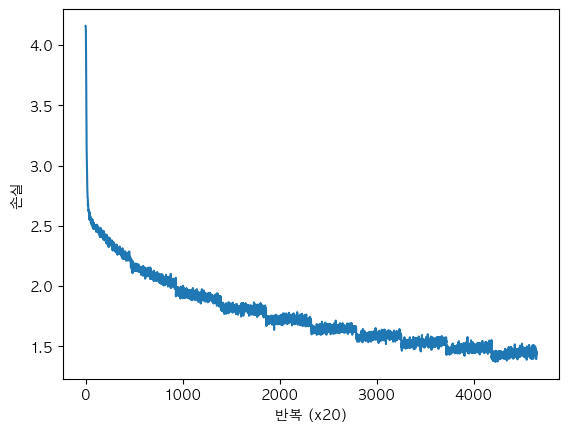

In [8]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import platform

# 한글 폰트 설정 (운영체제별 자동 적용)
if platform.system() == 'Darwin':  # macOS
    plt.rc('font', family='AppleGothic')
elif platform.system() == 'Windows':  # Windows
    plt.rc('font', family='Malgun Gothic')
else:  # Linux (Colab 포함)
    plt.rc('font', family='NanumGothic')

plt.rcParams['axes.unicode_minus'] = False  # 마이너스 부호 깨짐 방지
trainer.plot()

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

def similarity_heatmap(query, word_to_id, id_to_word, word_vecs, top=5):
    words = [query]
    vectors = [word_vecs[word_to_id[query]]]

    for word, _ in most_similar(query, word_to_id, id_to_word, word_vecs, top=top, print_result=False):
        words.append(word)
        vectors.append(word_vecs[word_to_id[word]])

    sim_matrix = np.dot(vectors, np.transpose(vectors))

    plt.figure(figsize=(8, 6))
    sns.heatmap(sim_matrix, xticklabels=words, yticklabels=words, annot=True, cmap='coolwarm')
    plt.title(f"Similarity Heatmap for '{query}' and related words")
    plt.show()

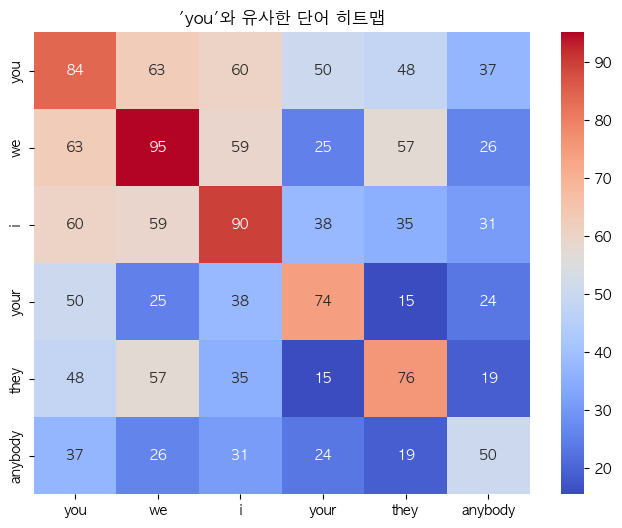

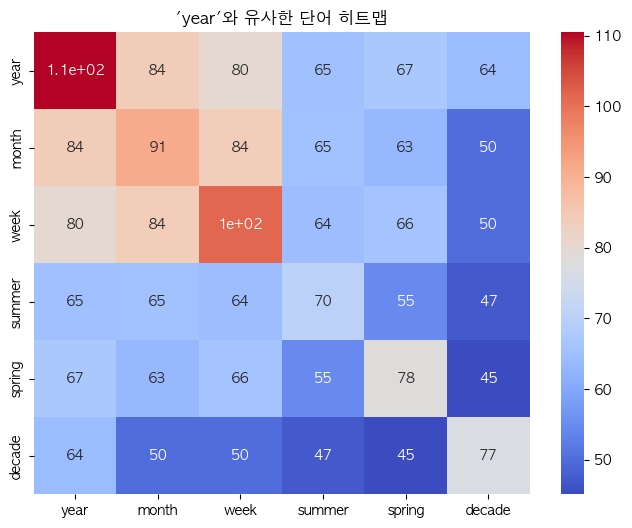

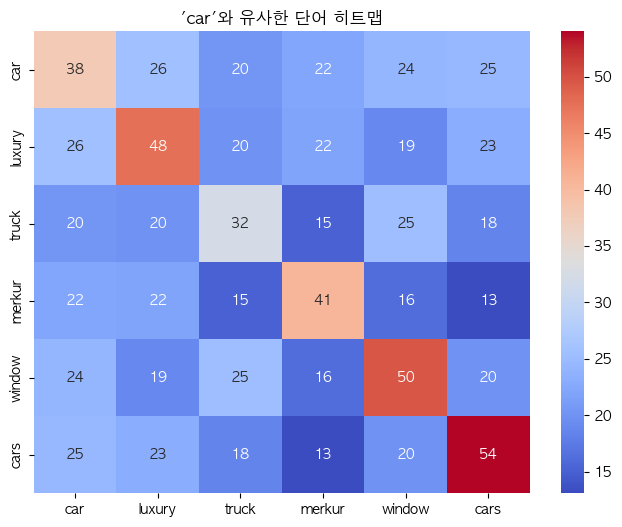

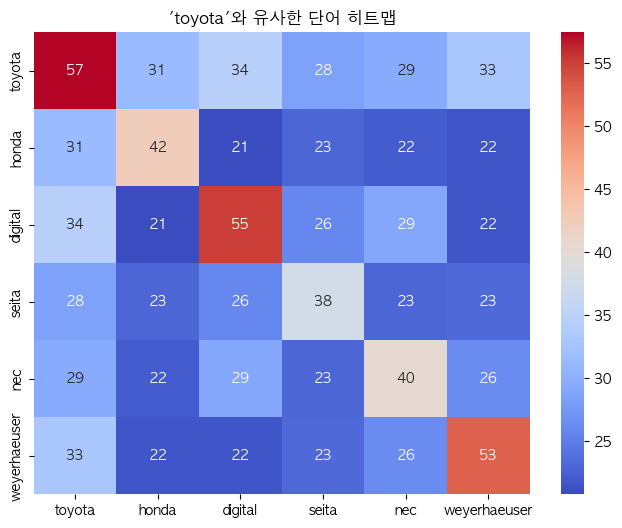

In [3]:
# 히트맵 시각화용 코드
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import platform
from common.util import most_similar

# 한글 폰트 설정
if platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')
elif platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
else:
    plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

# 학습된 파라미터 불러오기
with open('source/deep-learning-from-scratch-2/ch04/cbow_params.pkl', 'rb') as f:
    params = pickle.load(f)
    word_vecs = params['word_vecs']
    word_to_id = params['word_to_id']
    id_to_word = params['id_to_word']

# 유사도 히트맵 함수
def similarity_heatmap(query, word_to_id, id_to_word, word_vecs, top=5):
    words = [query]
    vectors = [word_vecs[word_to_id[query]]]

    results = most_similar(query, word_to_id, id_to_word, word_vecs, top=top, print_result=False)
    for word, _ in results:
        words.append(word)
        vectors.append(word_vecs[word_to_id[word]])

    sim_matrix = np.dot(vectors, np.transpose(vectors))

    plt.figure(figsize=(8, 6))
    sns.heatmap(sim_matrix, xticklabels=words, yticklabels=words, annot=True, cmap='coolwarm')
    plt.title(f"'{query}'와 유사한 단어 히트맵")
    plt.show()

# 예시 실행
querys = ['you', 'year', 'car', 'toyota']
for q in querys:
    similarity_heatmap(q, word_to_id, id_to_word, word_vecs, top=5)